### Subagents

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

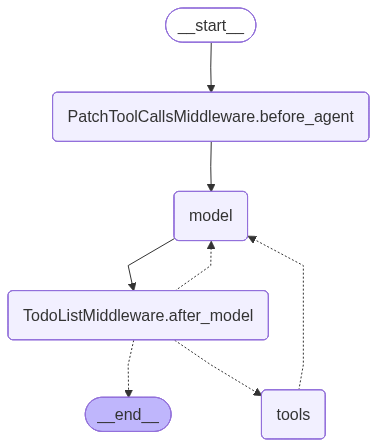

In [4]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": "groq:qwen/qwen3-32b",  # Optional override, defaults to main agent model

}
subagents=[research_subagent]

agent=create_deep_agent(
    model="openai:gpt-5.4",
    subagents=subagents
)
agent


In [ ]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "Reserach about LLM Gateways and provide me a detailed summary.",       
          }],
          
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reserach about LLM Gateways and provide me a detailed summary.
================================== Ai Message ==================================

[{'arguments': '{"todos":[{"content":"Research LLM gateways: definitions, capabilities, vendors, architectures, tradeoffs, and use cases","status":"in_progress"},{"content":"Synthesize findings into a detailed structured summary with recommendations and evaluation criteria","status":"pending"}]}', 'call_id': 'call_1Tsqtrx6vGERvieVkfzZDOfr', 'name': 'write_todos', 'type': 'function_call', 'id': 'fc_0b2a2df563fbc2fc006a2179d475a88192b9090e73857afff8', 'status': 'completed'}]
Tool Calls:
  write_todos (call_1Tsqtrx6vGERvieVkfzZDOfr)
 Call ID: call_1Tsqtrx6vGERvieVkfzZDOfr
  Args:
    todos: [{'content': 'Research LLM gateways: definitions, capabilities, vendors, architectures, tradeoffs, and use cases', 'status': 'in_progress'}, {'content': 'Synthesize findings into